# Affinity Classification Diagnostics

This notebook computes a compact set of diagnostic metrics for ordinal affinity labels on `(abstract, question)` pairs.

Metrics included:
1. Confusion matrix against expert labels
2. Per-class recall
3. Quadratic Weighted Kappa
4. Mean signed error
5. Reliability curve

Optional: cluster bootstrap confidence intervals (disabled by default).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, cohen_kappa_score

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [2]:
# Label definitions (edit only if your taxonomy changes).
LABEL_ORDER = ["Low", "Moderate", "High"]
LABEL_TO_NUM = {"Low": 0, "Moderate": 1, "High": 2}
NUM_TO_LABEL = {0: "Low", 1: "Moderate", 2: "High"}


def normalize_label(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, np.integer)):
        return NUM_TO_LABEL.get(int(v), np.nan)
    s = str(v).strip()
    s_low = s.lower()
    if s_low in {"low", "moderate", "high"}:
        return s_low.capitalize()
    return np.nan


# Hardcoded column names used throughout this notebook.
expert_col = "Evaluator_Affinity_Level"
prediction_col = "affinity_level"
abstract_id_col = "Abstract_Index"
model_col = "Model_Slug"

agreement_strength_col = None
panel_vote_cols = []

# Optional: per-model signed-bias diagnostics.
model_prediction_cols = []

# Optional cluster bootstrap (disabled by default).
RUN_BOOTSTRAP = False
N_BOOT = 500
BOOTSTRAP_SEED = 42

## Load Data

The loader tries likely project files first (including benchmark and calibration outputs), then you can override `input_path` manually if needed.

In [3]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
bench_root = repo_root / "data" / "results" / "affinity_benchmark"
calib_root = repo_root / "data" / "results" / "affinity_calibration"

# benchmark_run_dir_names = ["20260422_212121_1", "20260422_212121_4", "20260422_212121_3"]
benchmark_run_dir_names = ["20260625_140659"]
    
# calibration_run_dir_names = ["20260601_dummy_100_abstracts_v3"]
# calibration_run_dir_names = ["20260618_Mark_batch1_v2"]
calibration_run_dir_names = ["20260618_Mark_batch1_v3"]
benchmark_input_filename = "adjudicated_ra_model_rows.csv"
# calibration_input_filename = "calibration_dummy_abstract_question_affinities.csv"
calibration_input_filename = "calibration_abstract_question_affinities.csv"

def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError(
            "utf-8", b"", 0, 1, f"Unable to decode CSV file: {path}"
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

benchmark_frames, selected_benchmark_dirs = collect_frames(
    bench_root, benchmark_run_dir_names, benchmark_input_filename, "benchmark"
)
calibration_frames, selected_calibration_dirs = collect_frames(
    calib_root, calibration_run_dir_names, calibration_input_filename, "calibration"
)

bench_df = pd.concat(benchmark_frames, ignore_index=True)
calib_df = pd.concat(calibration_frames, ignore_index=True)
df_raw = pd.merge(
    bench_df,
    calib_df,
    on=["Abstract_Index", "RA2025_ID"],
    how="inner",
    suffixes=("_bench", "_calib"),
)

print("Benchmark run directories:", [p.name for p in selected_benchmark_dirs])
print("Calibration run directories:", [p.name for p in selected_calibration_dirs])
print("Calibration abstracts:", calib_df['Abstract_Index'].nunique())
print("Benchmark abstracts:", bench_df['Abstract_Index'].nunique())
print("Rows loaded:", len(df_raw))
print(f"Columns ({len(df_raw.columns)}): {list(df_raw.columns)}")
display(df_raw.head(10))

Benchmark run directories: ['20260625_140659']
Calibration run directories: ['20260618_Mark_batch1_v3']
Calibration abstracts: 21
Benchmark abstracts: 21
Rows loaded: 762
Columns (23): ['Abstract_Index', 'Document Title_bench', 'RA2025_ID', 'RA_Question_bench', 'Cosine_x100', 'LLM_Affinity', 'LLM_Affinity_Reason', 'Model_Slug', 'Run_ID_bench', 'Abstract_Index_Norm', 'affinity_level', 'Final_Affinity', 'Final_Method', 'Final_Reason', 'Source_Type_bench', 'Document Title_calib', 'RA_Question_calib', 'Evaluator_Affinity', 'Evaluator_Affinity_Level', 'Evaluator_Affinity_Reason', 'Source_Evaluator', 'Run_ID_calib', 'Source_Type_calib']


,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Final_Reason,Source_Type_bench,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib
0,1,Scenario Reduction Network Based on Wasserstei...,41,what additional probabilistic planning methods...,48.1019,105.0,Directly addresses computational efficiency an...,gemini-3.1-flash-lite,20260625_140659,1,...,NaN,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional probabilistic planning methods...,70,High,NaN,Mark,20260618_Mark_batch1_v3,calibration
1,1,Scenario Reduction Network Based on Wasserstei...,42,what additional planning models and methods ar...,41.1134,95.0,Directly improves the ability to model and pla...,gemini-3.1-flash-lite,20260625_140659,1,...,Strong consensus across all models that the pa...,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration
2,1,Scenario Reduction Network Based on Wasserstei...,47,how do system operators adequately account for...,40.4033,65.0,Scenario reduction techniques are essential fo...,gemini-3.1-flash-lite,20260625_140659,1,...,Moderate signals; the method can be used for e...,benchmark,Scenario Reduction Network Based on Wasserstei...,How do system operators adequately account for...,30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration
3,1,Scenario Reduction Network Based on Wasserstei...,35,"what models and methods, including testing, ar...",34.7982,40.0,Tangentially related as it provides a method t...,gemini-3.1-flash-lite,20260625_140659,1,...,NaN,benchmark,Scenario Reduction Network Based on Wasserstei...,"What models and methods, including testing, ar...",30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration
4,1,Scenario Reduction Network Based on Wasserstei...,48,what additional planning models and methods ar...,34.3618,70.0,Scenario reduction is critical for modeling lo...,gemini-3.1-flash-lite,20260625_140659,1,...,Resolved as a useful computational tool for mo...,benchmark,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration
5,1,Scenario Reduction Network Based on Wasserstei...,43,what changes can be incorporated into the tran...,33.7334,50.0,Supports the computational needs of complex in...,gemini-3.1-flash-lite,20260625_140659,1,...,Consistent view that the tool supports the com...,benchmark,Scenario Reduction Network Based on Wasserstei...,What changes can be incorporated into the tran...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration
6,1,Scenario Reduction Network Based on Wasserstei...,24,how can the risk of high-impact low-probabilit...,32.3158,45.0,Scenario reduction can help in managing the co...,gemini-3.1-flash-lite,20260625_140659,1,...,Conflict resolved by noting that while scenari...,benchmark,Scenario Reduction Network Based on Wasserstei...,How can the risk of high-impact low-probabilit...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration
7,1,Scenario Reduction Network Based on Wasserstei...,39,what technical models need to be added to long...,29.4057,40.0,Scenario reduction is a general tool that coul...,gemini-3.1-flash-lite,20260625_140659,1,...,Resolved as a general supporting tool for long...,benchmark,Scenario Reduction Network Based on Wasserstei...,What technical models need to be added to long...,30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration
8,1,Scenario Reduction Network Based on Wasserstei...,37,what studies and metrics are required to ident...,25.6859,50.0,Scenario reduction helps in identifying long-t...,gemini-3.1-flash-lite,20260625_140659,1,...,Consistent view that scenario reduction suppor...,benchmark,Scenario Reduction Network Based on Wa

In [4]:
# bench_df

In [5]:
required_cols = [expert_col, prediction_col, abstract_id_col]
missing_required = [c for c in required_cols if c not in df_raw.columns]

print("Hardcoded column mapping in use:")
print(f"  expert_col      -> {expert_col}")
print(f"  prediction_col  -> {prediction_col}")
print(f"  abstract_id_col -> {abstract_id_col}")

if missing_required:
    raise ValueError(
        f"Missing required columns in df_raw: {missing_required}. "
        "Please update hardcoded column names near the top of this notebook."
    )

Hardcoded column mapping in use:
  expert_col      -> Evaluator_Affinity_Level
  prediction_col  -> affinity_level
  abstract_id_col -> Abstract_Index


## Clean Labels

The cleaner normalizes variants such as `low`, `LOW`, `med`, `medium`, and `high`, then maps labels to ordinal values:

- Low = 0
- Medium = 1
- High = 2

In [6]:
# Assume labels are canonical: 'Low', 'Moderate', 'High'.
eval_df = df_raw.copy()
rows_before = len(eval_df)

expert_labels = eval_df[expert_col].map(normalize_label)
pred_labels = eval_df[prediction_col].map(normalize_label)
valid_mask = expert_labels.notna() & pred_labels.notna()

eval_df = eval_df.loc[valid_mask].copy()
eval_df['expert_num'] = expert_labels.loc[valid_mask].map(LABEL_TO_NUM).astype(int).to_numpy()
eval_df['pred_num'] = pred_labels.loc[valid_mask].map(LABEL_TO_NUM).astype(int).to_numpy()

rows_after = len(eval_df)
rows_removed = rows_before - rows_after

print(f'Rows before cleaning: {rows_before:,}')
print(f'Rows after cleaning:  {rows_after:,}')
print(f'Rows removed:         {rows_removed:,}')

print(f'Evaluated (abstract, question) pairs after cleaning: {rows_after:,}')
if abstract_id_col in eval_df.columns:
    print(f'Unique abstracts: {eval_df[abstract_id_col].nunique():,}')
else:
    print('Unique abstracts: not available (abstract_id_col not found).')
print(f'Unique abstract indices: {df_raw.Abstract_Index.unique().size:,}')

Rows before cleaning: 762
Rows after cleaning:  692
Rows removed:         70
Evaluated (abstract, question) pairs after cleaning: 692
Unique abstracts: 21
Unique abstract indices: 21


## Metric 1: Confusion Matrix Against Expert Labels

In [7]:
eval_df

,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib,expert_num,pred_num
0,1,Scenario Reduction Network Based on Wasserstei...,41,what additional probabilistic planning methods...,48.1019,105.0,Directly addresses computational efficiency an...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,What additional probabilistic planning methods...,70,High,NaN,Mark,20260618_Mark_batch1_v3,calibration,2,2
1,1,Scenario Reduction Network Based on Wasserstei...,42,what additional planning models and methods ar...,41.1134,95.0,Directly improves the ability to model and pla...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,2
2,1,Scenario Reduction Network Based on Wasserstei...,47,how do system operators adequately account for...,40.4033,65.0,Scenario reduction techniques are essential fo...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,How do system operators adequately account for...,30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration,0,1
3,1,Scenario Reduction Network Based on Wasserstei...,35,"what models and methods, including testing, ar...",34.7982,40.0,Tangentially related as it provides a method t...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,"What models and methods, including testing, ar...",30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration,0,0
4,1,Scenario Reduction Network Based on Wasserstei...,48,what additional planning models and methods ar...,34.3618,70.0,Scenario reduction is critical for modeling lo...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,281,Minimum Energy Demands of Energy Storages for ...,35,"what models and methods, including testing, ar...",34.0629,80.0,Quantifies energy storage's ability to provide...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,"What models and methods, including testing, ar...",50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,1
758,281,Minimum Energy Demands of Energy Storages for ...,33,how should the definitions of services for ibr...,33.4532,65.0,Defines frequency support as a service but doe...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,How should the definitions of services for IBR...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,1
759,281,Minimum Energy Demands of Energy Storages for ...,34,"what methods could determine the need, suffici...",25.3795,35.0,No direct link to voltage control or system st...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,"What methods could determine the need, suffici...",30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration,0,0
760,281,Minimum Energy Demands of Energy Storages for ...,36,what system services can be designed to enable...,20.4638,100.0,Directly designs a service (DOEFC) enabling en...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,What system services can be designed to enable...,70,High,NaN,Mark,20260618_Mark_batch1_v3,calibration,2,2


,Predicted Low,Predicted Medium,Predicted High
Expert Low,156,131,42
Expert Medium,77,113,90
Expert High,2,16,65


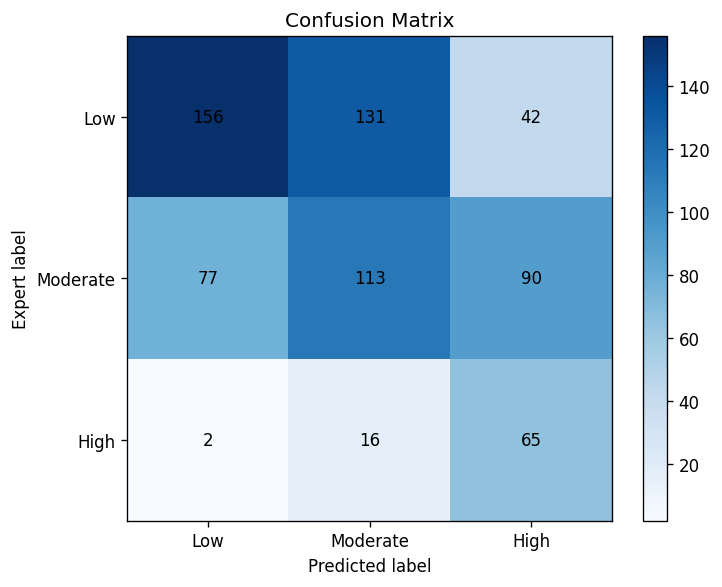

In [8]:
y_true = eval_df['expert_num'].to_numpy()
y_pred = eval_df['pred_num'].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
cm_df = pd.DataFrame(
    cm,
    index=['Expert Low', 'Expert Medium', 'Expert High'],
    columns=['Predicted Low', 'Predicted Medium', 'Predicted High'],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Low', 'Moderate', 'High'])
ax.set_yticklabels(['Low', 'Moderate', 'High'])
ax.set_xlabel('Predicted label')
ax.set_ylabel('Expert label')
ax.set_title('Confusion Matrix')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [9]:
eval_df

,Abstract_Index,Document Title_bench,RA2025_ID,RA_Question_bench,Cosine_x100,LLM_Affinity,LLM_Affinity_Reason,Model_Slug,Run_ID_bench,Abstract_Index_Norm,...,Document Title_calib,RA_Question_calib,Evaluator_Affinity,Evaluator_Affinity_Level,Evaluator_Affinity_Reason,Source_Evaluator,Run_ID_calib,Source_Type_calib,expert_num,pred_num
0,1,Scenario Reduction Network Based on Wasserstei...,41,what additional probabilistic planning methods...,48.1019,105.0,Directly addresses computational efficiency an...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,What additional probabilistic planning methods...,70,High,NaN,Mark,20260618_Mark_batch1_v3,calibration,2,2
1,1,Scenario Reduction Network Based on Wasserstei...,42,what additional planning models and methods ar...,41.1134,95.0,Directly improves the ability to model and pla...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,2
2,1,Scenario Reduction Network Based on Wasserstei...,47,how do system operators adequately account for...,40.4033,65.0,Scenario reduction techniques are essential fo...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,How do system operators adequately account for...,30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration,0,1
3,1,Scenario Reduction Network Based on Wasserstei...,35,"what models and methods, including testing, ar...",34.7982,40.0,Tangentially related as it provides a method t...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,"What models and methods, including testing, ar...",30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration,0,0
4,1,Scenario Reduction Network Based on Wasserstei...,48,what additional planning models and methods ar...,34.3618,70.0,Scenario reduction is critical for modeling lo...,gemini-3.1-flash-lite,20260625_140659,1,...,Scenario Reduction Network Based on Wasserstei...,What additional planning models and methods ar...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
757,281,Minimum Energy Demands of Energy Storages for ...,35,"what models and methods, including testing, ar...",34.0629,80.0,Quantifies energy storage's ability to provide...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,"What models and methods, including testing, ar...",50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,1
758,281,Minimum Energy Demands of Energy Storages for ...,33,how should the definitions of services for ibr...,33.4532,65.0,Defines frequency support as a service but doe...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,How should the definitions of services for IBR...,50,Moderate,NaN,Mark,20260618_Mark_batch1_v3,calibration,1,1
759,281,Minimum Energy Demands of Energy Storages for ...,34,"what methods could determine the need, suffici...",25.3795,35.0,No direct link to voltage control or system st...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,"What methods could determine the need, suffici...",30,Low,NaN,Mark,20260618_Mark_batch1_v3,calibration,0,0
760,281,Minimum Energy Demands of Energy Storages for ...,36,what system services can be designed to enable...,20.4638,100.0,Directly designs a service (DOEFC) enabling en...,mistral-large-3-675b-cloud,20260625_140659,281,...,Minimum Energy Demands of Energy Storages for ...,What system services can be designed to enable...,70,High,NaN,Mark,20260618_Mark_batch1_v3,calibration,2,2


Model: gemini-3.1-flash-lite (n=120) - CM same as original? True


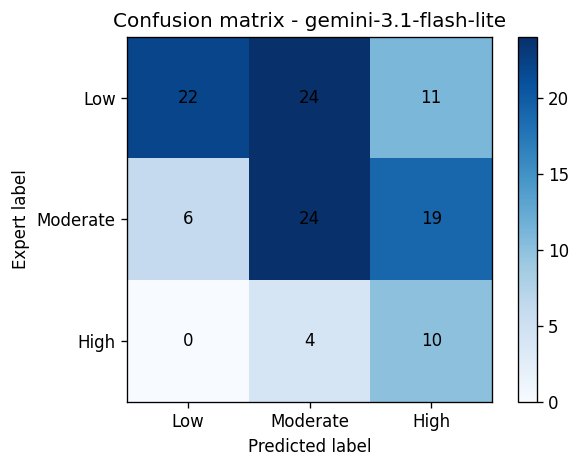

Model: gemma4-31b-cloud (n=104) - CM same as original? True


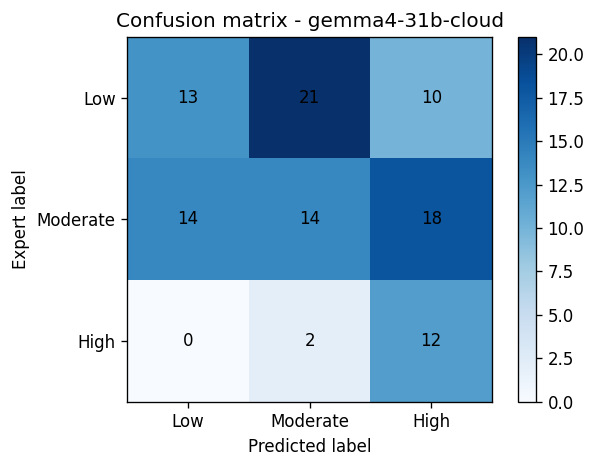

Model: gpt-5.4 (n=120) - CM same as original? True


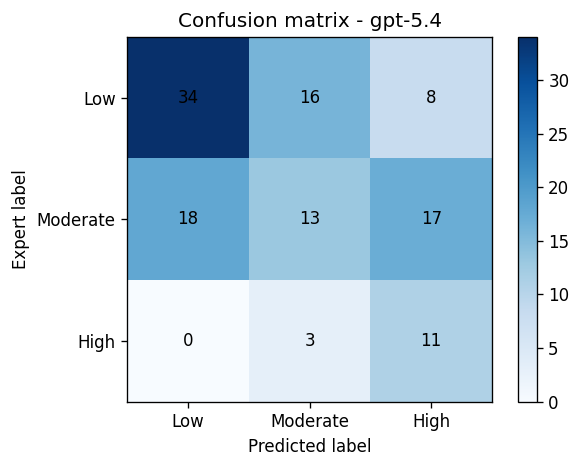

Model: gpt-5.4-mini (n=117) - CM same as original? True


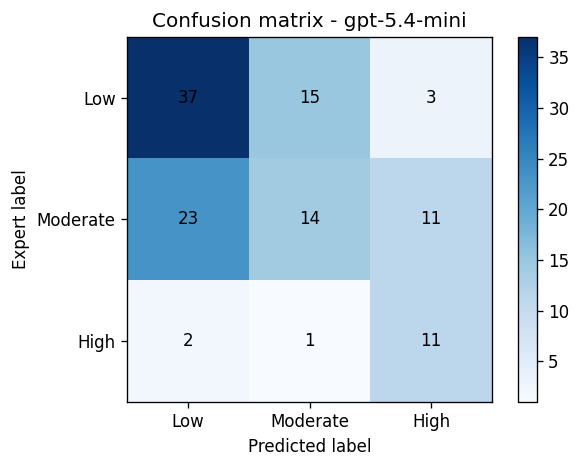

Model: ministral-3-14b-cloud (n=117) - CM same as original? True


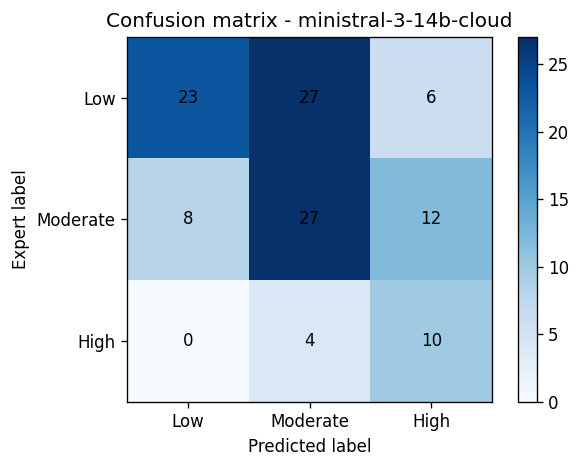

Model: mistral-large-3-675b-cloud (n=114) - CM same as original? True


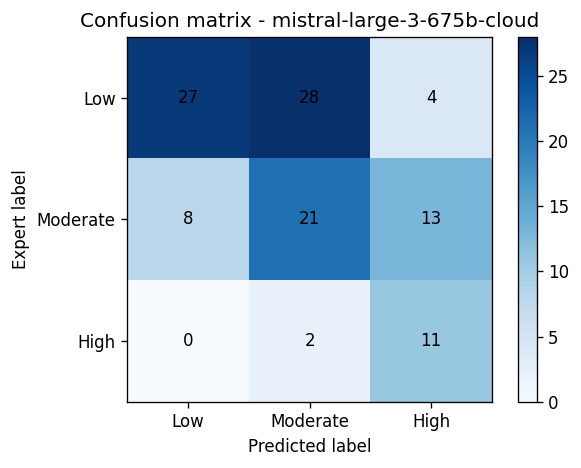

In [10]:
# Alternate confusion matrix using the primary configured columns.
# This compares expert labels in `expert_col` against predictions in `prediction_col`.
if expert_col is None or prediction_col is None:
    print('Skipping confusion matrix: required columns not configured.')
elif expert_col not in eval_df.columns or prediction_col not in eval_df.columns:
    print('Skipping confusion matrix: required columns not found in dataframe (', expert_col, ',', prediction_col, ')')
else:
    def _clean_pairwise(df, expert_col_name, pred_col_name):
        temp = df[[expert_col_name, pred_col_name]].copy()
        temp[expert_col_name] = temp[expert_col_name].map(normalize_label)
        temp[pred_col_name] = temp[pred_col_name].map(normalize_label)
        temp = temp.dropna()
        return temp

    labels = [0, 1, 2]
    tick_labels = ['Low', 'Moderate', 'High']

    def _plot_cm(cm, title=None, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 4))
        else:
            fig = ax.figure
        im = ax.imshow(cm, cmap='Blues')
        ax.set_xticks([0, 1, 2])
        ax.set_yticks([0, 1, 2])
        ax.set_xticklabels(tick_labels)
        ax.set_yticklabels(tick_labels)
        if title:
            ax.set_title(title)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('Expert label')
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(int(cm[i, j])), ha='center', va='center', color='black')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        return fig, ax

    if model_col in eval_df.columns:
        for m, g in eval_df.groupby(model_col):
            y_true_orig = g['expert_num'].to_numpy()
            y_pred_orig = g['pred_num'].to_numpy()
            cm_orig = confusion_matrix(y_true_orig, y_pred_orig, labels=labels)

            temp = _clean_pairwise(g, expert_col, prediction_col)
            if temp.empty:
                print(f'Model: {m} - no valid rows after cleaning (n=0)')
                continue

            y_true_alt = temp[expert_col].map(LABEL_TO_NUM).astype(int).to_numpy()
            y_pred_alt = temp[prediction_col].map(LABEL_TO_NUM).astype(int).to_numpy()
            cm_alt = confusion_matrix(y_true_alt, y_pred_alt, labels=labels)

            same = np.array_equal(cm_orig, cm_alt)
            print(f'Model: {m} (n={len(g)}) - CM same as original? {same}')

            if same:
                _ = _plot_cm(cm_alt, title=f'Confusion matrix - {m}')
                plt.show()
            else:
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                _plot_cm(cm_orig, title=f'Original CM - {m}', ax=axes[0])
                _plot_cm(cm_alt, title=f'Recomputed CM - {m}', ax=axes[1])
                plt.show()
    else:
        temp = _clean_pairwise(eval_df, expert_col, prediction_col)
        if temp.empty:
            print('No valid rows after cleaning (n=0)')
        else:
            y_true_alt = temp[expert_col].map(LABEL_TO_NUM).astype(int).to_numpy()
            y_pred_alt = temp[prediction_col].map(LABEL_TO_NUM).astype(int).to_numpy()
            cm_alt = confusion_matrix(y_true_alt, y_pred_alt, labels=labels)
            print('Confusion matrix (overall):')
            display(pd.DataFrame(cm_alt, index=['Expert Low', 'Expert Medium', 'Expert High'], columns=['Predicted Low', 'Predicted Medium', 'Predicted High']))

            cm_orig_overall = confusion_matrix(eval_df['expert_num'].to_numpy(), eval_df['pred_num'].to_numpy(), labels=labels)
            same_overall = np.array_equal(cm_orig_overall, cm_alt)
            print('Original and recomputed matrices identical? ', same_overall)
            if same_overall:
                _ = _plot_cm(cm_alt, title='Confusion matrix (overall)')
                plt.show()
            else:
                fig, axes = plt.subplots(1, 2, figsize=(12, 4))
                _plot_cm(cm_orig_overall, title='Original CM (overall)', ax=axes[0])
                _plot_cm(cm_alt, title='Recomputed CM (overall)', ax=axes[1])
                plt.show()

## Metric 2: Per-Class Recall

In [11]:
recalls = recall_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
recall_df = pd.DataFrame({
    'Class': LABEL_ORDER,
    'Recall': recalls,
    'Interpretation': [
        'Ability to identify low-affinity pairs',
        'Ability to identify medium-affinity pairs',
        'Ability to identify high-affinity pairs',
    ],
})
display(recall_df)

,Class,Recall,Interpretation
0,Low,0.474164,Ability to identify low-affinity pairs
1,Moderate,0.403571,Ability to identify medium-affinity pairs
2,High,0.783133,Ability to identify high-affinity pairs


## Metric 3 and 4: Quadratic Weighted Kappa and Mean Signed Error

In [12]:
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
mean_signed_error = float(np.mean(y_pred - y_true))

print(f'Quadratic Weighted Kappa = {qwk:.4f}')
print(f'Mean signed error        = {mean_signed_error:.4f}')

if model_prediction_cols:
    model_bias_rows = []
    for col in model_prediction_cols:
        if col not in eval_df.columns:
            continue

        pred_clean = eval_df[col].map(normalize_label)
        temp = eval_df[['expert_num']].copy()
        temp['pred_clean'] = pred_clean
        temp = temp.dropna(subset=['pred_clean'])
        if temp.empty:
            continue

        temp['pred_num_model'] = temp['pred_clean'].map(LABEL_TO_NUM).astype(int)
        mse_model = float(np.mean(temp['pred_num_model'] - temp['expert_num']))
        model_bias_rows.append({'model_prediction_col': col, 'mean_signed_error': mse_model, 'n_pairs': len(temp)})

    if model_bias_rows:
        display(pd.DataFrame(model_bias_rows).sort_values('mean_signed_error', ascending=False))
    else:
        print('No valid model-level bias rows were computed.')

Quadratic Weighted Kappa = 0.4002
Mean signed error        = 0.3006


## Metric 5: Reliability Curve

If `agreement_strength_col` is present, it is used directly.
Otherwise, if `panel_vote_cols` is provided, agreement strength is computed as the fraction of panel votes matching the final predicted label.

In [13]:
reliability_df = None

def compute_agreement_strength(row, pred_col_name, vote_cols):
    final_label = normalize_label(row[pred_col_name])
    votes = row[vote_cols].dropna()
    if len(votes) == 0:
        return np.nan
    votes_clean = votes.map(normalize_label)
    votes_clean = votes_clean.dropna()
    if len(votes_clean) == 0 or pd.isna(final_label):
        return np.nan
    return float((votes_clean == final_label).sum() / len(votes_clean))

if agreement_strength_col is not None and agreement_strength_col in eval_df.columns:
    work = eval_df.copy()
    work['agreement_strength'] = pd.to_numeric(work[agreement_strength_col], errors='coerce')
elif panel_vote_cols:
    missing_votes = [c for c in panel_vote_cols if c not in eval_df.columns]
    if missing_votes:
        print(f'Skipping reliability curve: missing panel vote columns: {missing_votes}')
        work = None
    else:
        work = eval_df.copy()
        work['agreement_strength'] = work.apply(
            compute_agreement_strength, axis=1, args=(prediction_col, panel_vote_cols)
        )
else:
    print('Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.')
    work = None

if work is not None:
    rel = work.dropna(subset=['agreement_strength']).copy()
    rel = rel[(rel['agreement_strength'] >= 0.0) & (rel['agreement_strength'] <= 1.0)].copy()

    if len(rel) == 0:
        print('Skipping reliability curve: no usable agreement strength values in [0, 1].')
    else:
        rel['is_correct'] = (rel['pred_num'] == rel['expert_num']).astype(int)

        bins = [0.0, 0.5, 0.67, 0.83, 1.0]
        rel['agreement_bin'] = pd.cut(rel['agreement_strength'], bins=bins, include_lowest=True)

        reliability_df = (
            rel.groupby('agreement_bin', observed=False)
            .agg(n_cases=('is_correct', 'size'), accuracy=('is_correct', 'mean'))
            .reset_index()
        )
        reliability_df = reliability_df[reliability_df['n_cases'] > 0].copy()
        reliability_df['bin_midpoint'] = reliability_df['agreement_bin'].apply(lambda x: x.mid)

        display(reliability_df[['agreement_bin', 'n_cases', 'accuracy']])

        fig, ax = plt.subplots()
        ax.plot(reliability_df['bin_midpoint'], reliability_df['accuracy'], marker='o')
        ax.set_xlabel('Agreement strength (bin midpoint)')
        ax.set_ylabel('Accuracy vs expert')
        ax.set_title('Reliability Curve')
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.


## Optional: Cluster Bootstrap Confidence Intervals

Bootstrap resamples complete abstracts (clusters), not individual rows.

Set `RUN_BOOTSTRAP = True` near the top to run this section.

In [14]:
bootstrap_summary = None

if RUN_BOOTSTRAP:
    if abstract_id_col not in eval_df.columns:
        print('Bootstrap skipped: abstract_id_col is missing.')
    else:
        rng = np.random.default_rng(BOOTSTRAP_SEED)
        abstract_ids = pd.Series(eval_df[abstract_id_col].dropna().unique())

        if len(abstract_ids) == 0:
            print('Bootstrap skipped: no abstract IDs available.')
        else:
            qwk_samples = []
            mse_samples = []
            recall_samples = []

            for _ in range(N_BOOT):
                sampled_ids = rng.choice(abstract_ids.to_numpy(), size=len(abstract_ids), replace=True)
                sampled_parts = [eval_df[eval_df[abstract_id_col] == aid] for aid in sampled_ids]
                boot_df = pd.concat(sampled_parts, ignore_index=True)

                y_t = boot_df['expert_num'].to_numpy()
                y_p = boot_df['pred_num'].to_numpy()

                qwk_samples.append(cohen_kappa_score(y_t, y_p, weights='quadratic'))
                mse_samples.append(float(np.mean(y_p - y_t)))
                recall_samples.append(recall_score(y_t, y_p, labels=[0, 1, 2], average=None, zero_division=0))

            recall_arr = np.vstack(recall_samples)

            def ci(values, alpha=0.05):
                lo = np.nanpercentile(values, 100 * (alpha / 2))
                hi = np.nanpercentile(values, 100 * (1 - alpha / 2))
                return float(lo), float(hi)

            qwk_ci = ci(np.array(qwk_samples))
            mse_ci = ci(np.array(mse_samples))
            low_ci = ci(recall_arr[:, 0])
            med_ci = ci(recall_arr[:, 1])
            high_ci = ci(recall_arr[:, 2])

            bootstrap_summary = pd.DataFrame([
                {'Metric': 'Quadratic Weighted Kappa', 'CI_2.5%': qwk_ci[0], 'CI_97.5%': qwk_ci[1]},
                {'Metric': 'Recall Low', 'CI_2.5%': low_ci[0], 'CI_97.5%': low_ci[1]},
                {'Metric': 'Recall Medium', 'CI_2.5%': med_ci[0], 'CI_97.5%': med_ci[1]},
                {'Metric': 'Recall High', 'CI_2.5%': high_ci[0], 'CI_97.5%': high_ci[1]},
                {'Metric': 'Mean Signed Error', 'CI_2.5%': mse_ci[0], 'CI_97.5%': mse_ci[1]},
            ])
            display(bootstrap_summary)
else:
    print('Bootstrap disabled (RUN_BOOTSTRAP = False).')

Bootstrap disabled (RUN_BOOTSTRAP = False).


## Final Summary Table

In [15]:
summary_rows = [
    {'Quantity': 'Evaluated pairs', 'Value': int(len(eval_df))},
    {
        'Quantity': 'Unique abstracts',
        'Value': int(eval_df[abstract_id_col].nunique())
        if abstract_id_col in eval_df.columns
        else 'N/A',
    },
    {'Quantity': 'Quadratic Weighted Kappa', 'Value': float(qwk)},
    {'Quantity': 'Low recall', 'Value': float(recalls[0])},
    {'Quantity': 'Medium recall', 'Value': float(recalls[1])},
    {'Quantity': 'High recall', 'Value': float(recalls[2])},
    {'Quantity': 'Mean signed error', 'Value': float(mean_signed_error)},
]

if reliability_df is not None and len(reliability_df) > 0:
    summary_rows.extend([
        {'Quantity': 'Reliability curve available', 'Value': 'Yes'},
        {'Quantity': 'Lowest agreement-bin accuracy', 'Value': float(reliability_df['accuracy'].min())},
        {'Quantity': 'Highest agreement-bin accuracy', 'Value': float(reliability_df['accuracy'].max())},
    ])
else:
    summary_rows.append({'Quantity': 'Reliability curve available', 'Value': 'No'})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Quantity,Value
0,Evaluated pairs,692
1,Unique abstracts,21
2,Quadratic Weighted Kappa,0.400232
3,Low recall,0.474164
4,Medium recall,0.403571
5,High recall,0.783133
6,Mean signed error,0.300578
7,Reliability curve available,No


## Practical Decision Rules

- Good Quadratic Weighted Kappa and balanced recall across Low, Medium, and High: the three-class pipeline is likely acceptable.
- Poor Medium recall: the Medium category may be unstable; consider a binary first-stage classifier followed by adjudication of relevant cases.
- Good Low and High recall but weak Medium recall: the panel may be behaving as a binary relevant/not-relevant classifier.
- Positive mean signed error: the pipeline tends to overestimate affinity.
- Negative mean signed error: the pipeline tends to underestimate affinity.
- Mean signed error near zero: no average directional bias, but performance may still be poor.
- Increasing reliability curve: panel agreement or confidence is informative.
- Flat reliability curve: possible correlated or monoculture error.
- High-agreement cases with low accuracy: strong evidence of shared model bias relative to the expert.